# Importing Data

In [1]:
import sql
import pyodbc
import sqlalchemy
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Local SQL Server connection removed for GitHub.
# The original analysis outputs are preserved below.

In [3]:
%%sql
select top(5)* from superstore

SQL query executed locally (connection omitted)'

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Sales_Agent
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9599914550781,2,0.0,41.91360092163086,James Hall
2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400024414062,3,0.0,219.58200073242188,Olivia Brown
3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.619999885559082,2,0.0,6.871399879455566,Mason Taylor
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775146484375,5,0.44999998807907104,-383.031005859375,Olivia Brown
5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368000030517578,2,0.20000000298023224,2.516400098800659,John Carter


# EDA

### Top 10 Sales by States

In [4]:
%%sql state_sales <<
select top (10)State , round(sum(Sales),1) as Sales
    from superstore
    group by State
    ORDER BY Sales DESC;

SQL query executed locally (connection omitted)'

In [5]:
states = state_sales.DataFrame()
states

,State,Sales
0,California,457687.6
1,New York,310876.3
2,Texas,170188.0
3,Washington,138641.3
4,Pennsylvania,116511.9
5,Florida,89473.7
6,Illinois,80166.1
7,Ohio,78258.1
8,Michigan,76269.6
9,Virginia,70636.7


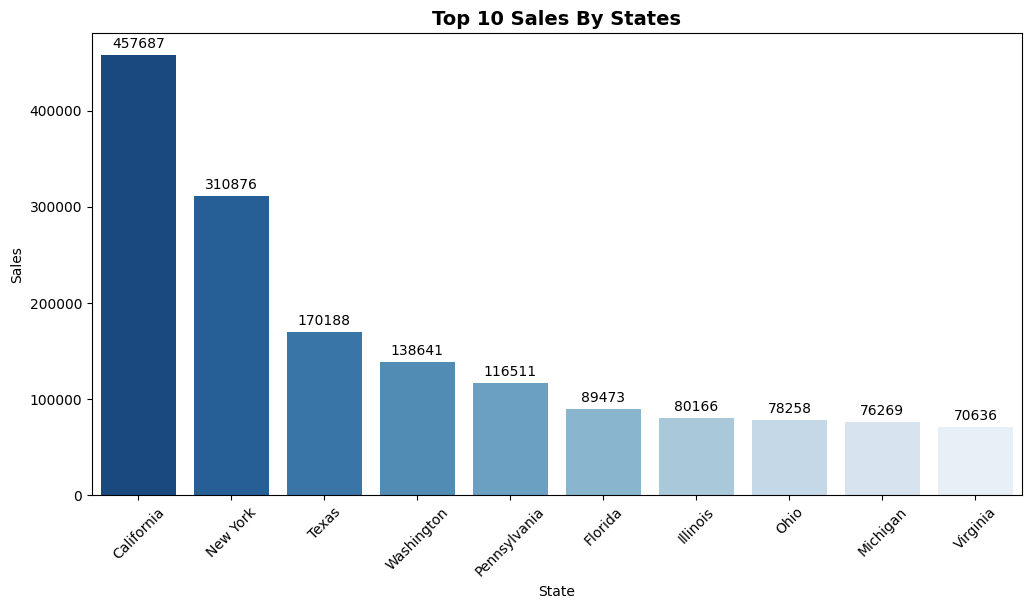

In [6]:
plt.figure(figsize=(12, 6))

state_s = sns.barplot(
    data=states,
    x='State',
    y='Sales',
    palette='Blues_r',
    hue='State',
    legend=False
)

for container in state_s.containers:
    state_s.bar_label(container, fmt='%d', padding=3)

plt.title('Top 10 Sales By States', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

## Sales Distribution

In [7]:
%%sql df_sales << 
SELECT Sales FROM superstore;

SQL query executed locally (connection omitted)'

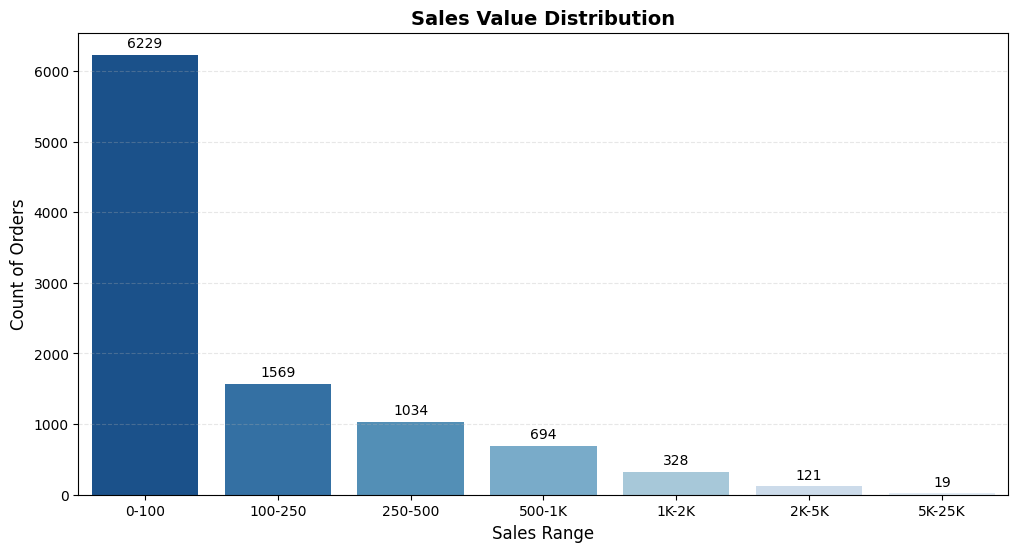

In [8]:
df_clean = df_sales.DataFrame()

custom_bins = [0, 100, 250, 500, 1000, 2000, 5000, 25000]
bin_labels = ['0-100', '100-250', '250-500', '500-1K', '1K-2K', '2K-5K', '5K-25K']

df_clean['Sales_Group'] = pd.cut(df_clean['Sales'], bins=custom_bins, labels=bin_labels, include_lowest=True)
group_counts = df_clean['Sales_Group'].value_counts().sort_index().reset_index()
group_counts.columns = ['Sales_Range', 'Count']
group_counts['Sales_Range'] = group_counts['Sales_Range'].astype(str)
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=group_counts, 
    x='Sales_Range', 
    y='Count', 
    palette='Blues_r', 
    hue='Sales_Range', 
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


plt.title('Sales Value Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sales Range', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

## Top Customers

In [9]:
 %%sql top_cus <<
 select top(10)Customer_Name,round(sum(Sales),1) as Sales, round(avg(Sales),1) as Sales_AVG,round(count(	Order_ID),1)as Order_Count
     from superstore
     group by Customer_Name
     order by Sales_AVG DESC;


SQL query executed locally (connection omitted)'

In [10]:
top_customer = top_cus.DataFrame()
top_customer

,Customer_Name,Sales,Sales_AVG,Order_Count
0,Mitch Willingham,5253.9,1751.3,3
1,Sean Miller,25043.1,1669.5,15
2,Tamara Chand,19052.2,1587.7,12
3,Grant Thornton,9351.2,1558.5,6
4,Tom Ashbrook,14595.6,1459.6,10
5,Hunter Lopez,12873.3,1170.3,11
6,Bill Shonely,10501.7,1166.9,9
7,Christopher Conant,12129.1,1102.6,11
8,Stefanie Holloman,2096.4,1048.2,2
9,Christopher Martinez,8954.0,895.4,10


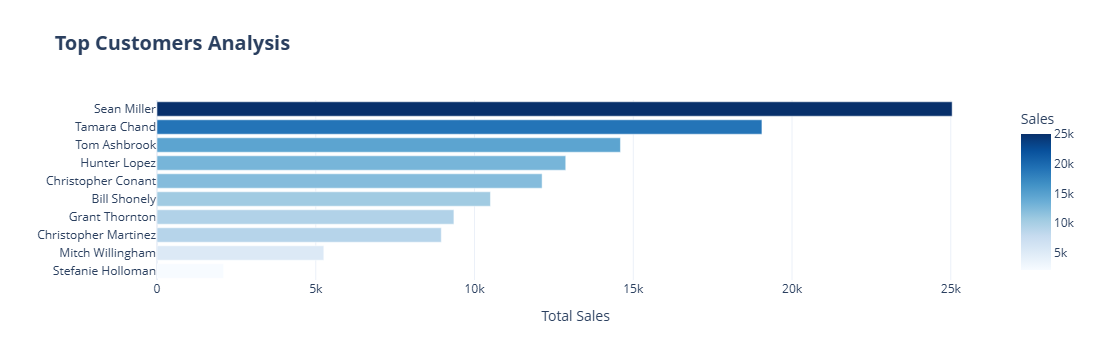

In [11]:
import plotly.express as px

fig = px.bar(
    top_customer,
    x="Sales",
    y="Customer_Name",
    orientation="h",
    title="<b>Top Customers Analysis</b>",
    hover_data={
        "Sales": ":.1f",
        "Sales_AVG": ":.1f",
        "Order_Count": True
    },
    labels={
        "Customer_Name": "Customer Name",
        
        "Sales_AVG": "Average Sales",
        "Order_Count": "Total Orders"
    },
    color="Sales",
    color_continuous_scale="Blues"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Total Sales",
    yaxis_title="",
    title_font_size=20,
    yaxis={'categoryorder':'total ascending'},
    hoverlabel=dict(
        bgcolor="white",
        font_size=13,
        font_family="Arial"
    )
)
fig.show()

## Correlation between sales, orders count, profit and discount

In [12]:
%%sql correlation <<
 select Sales,Discount,Profit
     from superstore


SQL query executed locally (connection omitted)'

In [13]:
df_clean=correlation.DataFrame()
df_clean

,Sales,Discount,Profit
0,261.959991,0.00,41.913601
1,731.940002,0.00,219.582001
2,14.620000,0.00,6.871400
3,957.577515,0.45,-383.031006
4,22.368000,0.20,2.516400
...,...,...,...
9989,25.247999,0.20,4.102800
9990,91.959999,0.00,15.633200
9991,258.575989,0.20,19.393200
9992,29.600000,0.00,13.320000


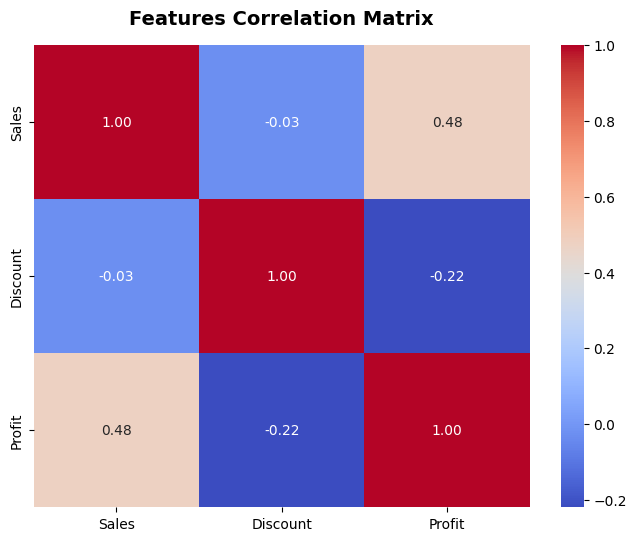

In [14]:
corr_matrix = df_clean[['Sales', 'Discount', 'Profit']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    )

plt.title('Features Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.show()

## Customer segmantation based on sales

In [15]:
%%sql customer_level<<
select Customer_Name, round(sum(Sales),0) as Sales,round(sum(Profit),0) as Profit,
case
    when sum(Sales) > (select round(avg(Sales),0) from superstore ) then 'Vip Customer'
    when sum(Sales) < (select round(avg(Sales),0) from superstore) then 'Normal Customer'
    when sum(Profit) < 0 then 'Bad Customers'
end as customer_level
from superstore 
group by Customer_Name 
order by Sales desc

SQL query executed locally (connection omitted)'

In [16]:
customer_level

Customer_Name,Sales,Profit,customer_level
Sean Miller,25043.0,-1981.0,Vip Customer
Tamara Chand,19052.0,8981.0,Vip Customer
Raymond Buch,15117.0,6976.0,Vip Customer
Tom Ashbrook,14596.0,4704.0,Vip Customer
Adrian Barton,14474.0,5445.0,Vip Customer
Ken Lonsdale,14175.0,807.0,Vip Customer
Sanjit Chand,14142.0,5757.0,Vip Customer
Hunter Lopez,12873.0,5622.0,Vip Customer
Sanjit Engle,12209.0,2651.0,Vip Customer
Christopher Conant,12129.0,2177.0,Vip Customer


In [17]:
# %%sql
# select avg(Sales)from superstore

SQL query executed locally (connection omitted)'

""
229.85800038516368


In [18]:
# %%sql
# select distinct 
#     percentile_cont(0.5) within group (order by Sales) over() as Median_Sales
# from superstore;

SQL query executed locally (connection omitted)'

Median_Sales
54.489999771118164


In [19]:
# %%sql sales_box<<
# select Sales from superstore

SQL query executed locally (connection omitted)'

<Axes: >

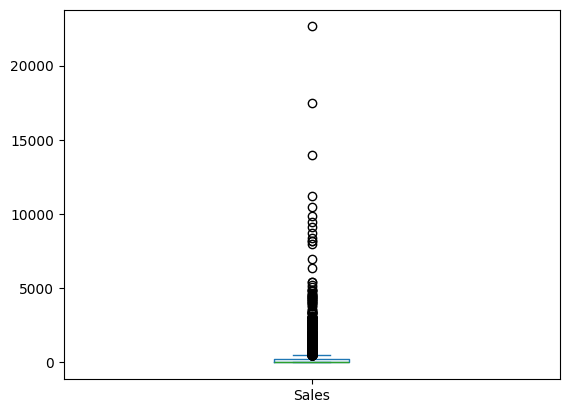

In [20]:
sales_outlier = sales_box.DataFrame()
sales_outlier.plot(kind='box')

### We must check data source

### Descovering bad customers

In [21]:
%%sql bad_cus <<
select Customer_Name, round(sum(Sales),0) as Sales,round(sum(Profit),0) as Profit
from superstore 
group by Customer_Name 
having sum(Profit) < 0
order by Profit 

SQL query executed locally (connection omitted)'

In [22]:
%config SqlMagic.displaylimit = None

displaylimit: Value None will be treated as 0 (no limit)

In [23]:
bad_cus

Customer_Name,Sales,Profit
Cindy Stewart,5690.0,-6626.0
Grant Thornton,9351.0,-4109.0
Luke Foster,3931.0,-3584.0
Sharelle Roach,3233.0,-3334.0
Henry Goldwyn,3248.0,-2798.0
Nathan Cano,2219.0,-2205.0
Sean Braxton,8058.0,-2083.0
Sean Miller,25043.0,-1981.0
Christine Phan,5888.0,-1850.0
Natalie Fritzler,8323.0,-1696.0


In [24]:
len(bad_cus)

155

In [25]:
%%sql total_cus <<
select Customer_Name, round(sum(Sales),0) as Sales,round(sum(Profit),0) as Profit
from superstore 
group by Customer_Name 

SQL query executed locally (connection omitted)'

In [26]:
len(total_cus)

793

In [27]:
bad_cus = len(bad_cus) / len(total_cus) * 100
print(f"{round(bad_cus, 0)}%")

20.0%


In [28]:
%%sql real_segmantation<<
create OR ALTER view r_c_l as
select  Customer_Name, round(sum(Sales),0) as Sales,round(sum(Profit),0) as Profit,
case
    when sum(Sales) > (select round(avg(Sales),0) from superstore ) then 'Vip Customer'
    when sum(Sales) < (select round(avg(Sales),0) from superstore) then 'Normal Customer'
end as customer_level
from superstore
group by Customer_Name
having sum(profit) > 0

SQL query executed locally (connection omitted)'

In [29]:
%%sql real_segmantation<< 
select * from r_c_l

SQL query executed locally (connection omitted)'

In [30]:
real_segmantation

Customer_Name,Sales,Profit,customer_level
Michael Chen,3806.0,698.0,Vip Customer
Brian Moss,7294.0,2199.0,Vip Customer
Tamara Chand,19052.0,8981.0,Vip Customer
Justin MacKendrick,2834.0,754.0,Vip Customer
Doug Bickford,1989.0,439.0,Vip Customer
Jesus Ocampo,1091.0,168.0,Vip Customer
John Huston,529.0,26.0,Vip Customer
Liz Carlisle,2095.0,87.0,Vip Customer
Tracy Collins,743.0,218.0,Vip Customer
Eugene Moren,4588.0,1319.0,Vip Customer


In [31]:
len(real_segmantation)

638

In [32]:
%%sql count_segmantation<<
select customer_level ,count(Customer_Name) as Count_Coustomers from r_c_l group by customer_level

SQL query executed locally (connection omitted)'

In [33]:
count_segmantation

customer_level,Count_Coustomers
Normal Customer,22
Vip Customer,616


### **We can segment customers based on the marketing strategy.**

## Sales over time

In [34]:
%%sql sales_year <<
select year(Ship_Date) as Years , sum(Sales) as Sales
from superstore
group by year(Ship_Date)
order by year(Ship_Date)

SQL query executed locally (connection omitted)'

In [35]:
sales_years = sales_year.DataFrame()
sales_years.style.hide(axis='index')

Years,Sales
2014,470383.192368
2015,479442.502368
2016,611325.751272
2017,730889.713054
2018,5159.696787


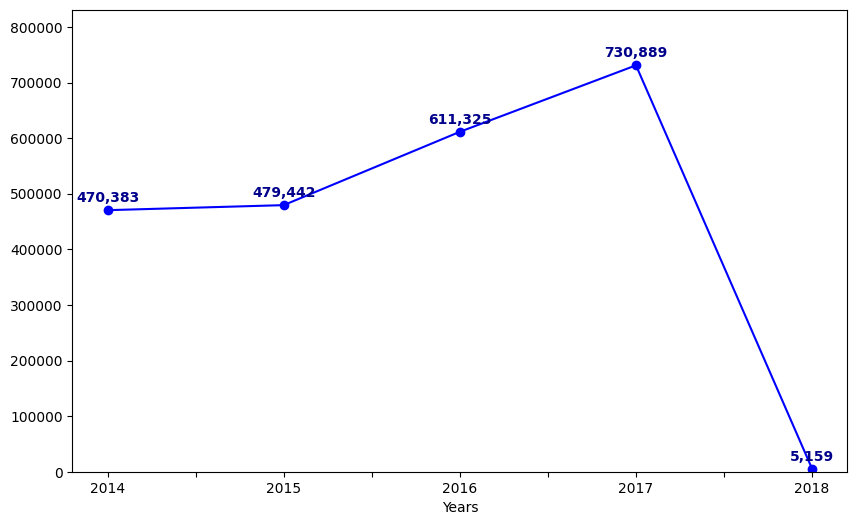

In [36]:
sales_years = sales_year.DataFrame().sort_values(by='Years')

sales_years['Years'] = sales_years['Years'].astype(str)

sales_years.set_index('Years', inplace=True)

ax = sales_years['Sales'].plot(kind='line', marker='o', color='b', figsize=(10, 6))

for i, val in enumerate(sales_years['Sales']):
    ax.text(i, val + 15000, f'{int(val):,}', ha='center', fontsize=10, fontweight='bold', color='darkblue')

plt.ylim(0, sales_years['Sales'].max() + 100000)
plt.show()